# Collecting Dataset

In [15]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Create a shortcut to the Gallery and Probe Set Folders to your MyDrive (or change the path)
gallery_path = '/content/drive/MyDrive/GallerySet'
probe_path = '/content/drive/MyDrive/ProbeSet'

# Arcface

**install** insighface package for google colab & pillow-heif for handling HEIF files

In [17]:
!pip install -U insightface

import torch
if torch.cuda.is_available():
  print('gpu is available')
  !pip install onnxruntime-gpu  # to use GPU
else:
  print('gpu is not available')
  !pip install onnxruntime

gpu is available


In [18]:
!pip install pillow-heif
from pillow_heif import register_heif_opener
register_heif_opener()

**prepare insightface module**

In [19]:
import insightface
from insightface.app import FaceAnalysis
from insightface.data import get_image as ins_get_image

app = FaceAnalysis()
app.prepare(ctx_id=0, det_thresh=0.5)

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

**ONYX graph inspection**

In [20]:
import onnx
model = onnx.load('/root/.insightface/models/buffalo_l/w600k_r50.onnx')
print(onnx.helper.printable_graph(model.graph))

graph torch-jit-export (
  %input.1[FLOAT, Nonex3x112x112]
) initializers (
  %layer1.0.bn1.weight[FLOAT, 64]
  %layer1.0.bn1.bias[FLOAT, 64]
  %layer1.0.bn1.running_mean[FLOAT, 64]
  %layer1.0.bn1.running_var[FLOAT, 64]
  %layer1.1.bn1.weight[FLOAT, 64]
  %layer1.1.bn1.bias[FLOAT, 64]
  %layer1.1.bn1.running_mean[FLOAT, 64]
  %layer1.1.bn1.running_var[FLOAT, 64]
  %layer1.2.bn1.weight[FLOAT, 64]
  %layer1.2.bn1.bias[FLOAT, 64]
  %layer1.2.bn1.running_mean[FLOAT, 64]
  %layer1.2.bn1.running_var[FLOAT, 64]
  %layer2.0.bn1.weight[FLOAT, 64]
  %layer2.0.bn1.bias[FLOAT, 64]
  %layer2.0.bn1.running_mean[FLOAT, 64]
  %layer2.0.bn1.running_var[FLOAT, 64]
  %layer2.1.bn1.weight[FLOAT, 128]
  %layer2.1.bn1.bias[FLOAT, 128]
  %layer2.1.bn1.running_mean[FLOAT, 128]
  %layer2.1.bn1.running_var[FLOAT, 128]
  %layer2.2.bn1.weight[FLOAT, 128]
  %layer2.2.bn1.bias[FLOAT, 128]
  %layer2.2.bn1.running_mean[FLOAT, 128]
  %layer2.2.bn1.running_var[FLOAT, 128]
  %layer2.3.bn1.weight[FLOAT, 128]
  %layer2.3

/tmp/ipykernel_6559/3736105999.py:3: DeprecationWarning: Deprecated since 1.19. Consider using onnx.printer.to_text() instead.
  print(onnx.helper.printable_graph(model.graph))


**feature extraction**

In [21]:
import os
import cv2
import numpy as np
from pillow_heif import register_heif_opener
from PIL import Image
register_heif_opener()

gallery_path = '/content/drive/MyDrive/GallerySet'
probe_path = '/content/drive/MyDrive/ProbeSet'

def extract_arcface_features(dataset_path):
  features = []
  labels = []
  filenames = []

  for person in sorted(os.listdir(dataset_path)):
    person_path = os.path.join(dataset_path, person)
    if not os.path.isdir(person_path):
      continue
    for file in sorted(os.listdir(person_path)):
      if not file.lower().endswith(('.jpg', '.jpeg', '.png', '.heic')):
        continue
      filepath = os.path.join(person_path, file)
      try:
        # Handle HEIC and regular images
        pil_img = Image.open(filepath).convert('RGB')
        img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        faces = app.get(img)
        if len(faces) == 0:
          print(f"  No face detected: {person}/{file}")
          continue
        if len(faces) > 1:
          print(f"  Warning: {len(faces)} faces detected in {person}/{file}, using largest")
        features.append(faces[0].normed_embedding)
        labels.append(person)
        filenames.append(file)
        print(f"  processed: {person}/{file}")
      except Exception as e:
        print(f"  Error on {person}/{file}: {e}")
  return np.array(features), labels, filenames

print("Extracting gallery features...")
gallery_features, gallery_labels, gallery_files = extract_arcface_features(gallery_path)
print(f"\nGallery: {len(gallery_features)} features extracted")

print("\nExtracting probe features...")
probe_features, probe_labels, probe_files = extract_arcface_features(probe_path)
print(f"\nProbe: {len(probe_features)} features extracted")

Extracting gallery features...
  processed: Aaron Park/IMG_0112.HEIC
  processed: Aaron Park/IMG_0272.jpg
  processed: Aaron Park/IMG_1453.HEIC
  processed: Aaron Park/IMG_2642.HEIC
  processed: Aaron Park/IMG_3938.HEIC
  processed: Aaron Park/IMG_4279.HEIC
  processed: Aaron Park/IMG_4512.HEIC
  processed: Aaron Park/IMG_4592.HEIC
  processed: Aaron Park/IMG_8261.HEIC
  processed: Aaron Park/IMG_9433.HEIC
  processed: Aaron Park/IMG_9576.HEIC
  processed: Aaron Park/IMG_9905.HEIC
  processed: Angelia/DSCN2263.JPG
  processed: Angelia/DSCN2286.JPG
  processed: Angelia/IMG_0375.heic
  processed: Angelia/IMG_0423.HEIC
  processed: Angelia/IMG_0734.HEIC
  processed: Angelia/IMG_1763.HEIC
  processed: Angelia/IMG_1785.HEIC
  processed: Angelia/IMG_2041.HEIC
  processed: Angelia/IMG_2468.HEIC
  processed: Angelia/IMG_2539.HEIC
  processed: Angelia/IMG_9406.HEIC
  processed: Angelia/IMG_9751.HEIC
  processed: Elyse Undan/IMG_5983.heic
  processed: Elyse Undan/IMG_5984.heic
  No face detected

# VGG

**install and prepare module**

In [22]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

vgg = models.vgg19(weights='DEFAULT')

feature_extractor = torch.nn.Sequential(
    vgg.features,
    vgg.avgpool,
    torch.nn.Flatten(),
    vgg.classifier[0],  # Linear 25088 --> 4096
    vgg.classifier[1],  # ReLU
).to(device)
feature_extractor.eval()

Using device: cuda
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 115MB/s] 


Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [23]:
import os
import numpy as np
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def extract_vgg_features(dataset_path):
  features = []
  labels = []
  filenames = []

  for person in sorted(os.listdir(dataset_path)):
    person_path = os.path.join(dataset_path, person)
    if not os.path.isdir(person_path):
      continue
    for file in sorted(os.listdir(person_path)):
      if not file.lower().endswith(('.jpg', '.jpeg', '.png', '.heic')):
        continue
      filepath = os.path.join(person_path, file)
      try:
        img = Image.open(filepath).convert('RGB')
        tensor = transform(img).unsqueeze(0).to(device)  # send to GPU
        with torch.no_grad():
          feat = feature_extractor(tensor)
        features.append(feat.squeeze().cpu().numpy())  # back to CPU
        labels.append(person)
        filenames.append(file)
        print(f"  processed: {person}/{file}")
      except Exception as e:
        print(f"  Error on {person}/{file}: {e}")

  return np.array(features), labels, filenames

print("Extracting VGG gallery features...")
vgg_gallery_features, vgg_gallery_labels, vgg_gallery_files = extract_vgg_features(gallery_path)
print(f"\nGallery: {len(vgg_gallery_features)} features extracted")

print("\nExtracting VGG probe features...")
vgg_probe_features, vgg_probe_labels, vgg_probe_files = extract_vgg_features(probe_path)
print(f"\nProbe: {len(vgg_probe_features)} features extracted")

Extracting VGG gallery features...
  processed: Aaron Park/IMG_0112.HEIC
  processed: Aaron Park/IMG_0272.jpg
  processed: Aaron Park/IMG_1453.HEIC
  processed: Aaron Park/IMG_2642.HEIC
  processed: Aaron Park/IMG_3938.HEIC
  processed: Aaron Park/IMG_4279.HEIC
  processed: Aaron Park/IMG_4512.HEIC
  processed: Aaron Park/IMG_4592.HEIC
  processed: Aaron Park/IMG_8261.HEIC
  processed: Aaron Park/IMG_9433.HEIC
  processed: Aaron Park/IMG_9576.HEIC
  processed: Aaron Park/IMG_9905.HEIC
  processed: Angelia/DSCN2263.JPG
  processed: Angelia/DSCN2286.JPG
  processed: Angelia/IMG_0375.heic
  processed: Angelia/IMG_0423.HEIC
  processed: Angelia/IMG_0734.HEIC
  processed: Angelia/IMG_1763.HEIC
  processed: Angelia/IMG_1785.HEIC
  processed: Angelia/IMG_2041.HEIC
  processed: Angelia/IMG_2468.HEIC
  processed: Angelia/IMG_2539.HEIC
  processed: Angelia/IMG_9406.HEIC
  processed: Angelia/IMG_9751.HEIC
  processed: Elyse Undan/IMG_5983.heic
  processed: Elyse Undan/IMG_5984.heic
  processed: E

# Downloading Extracted Files

In [24]:
import numpy as np

save_path = '/content/drive/MyDrive/'

# Save Arcface features
np.save(save_path + 'arcface_gallery_features.npy', gallery_features)
np.save(save_path + 'arcface_probe_features.npy', probe_features)
np.save(save_path + 'arcface_gallery_labels.npy', np.array(gallery_labels))
np.save(save_path + 'arcface_probe_labels.npy', np.array(probe_labels))

print("All Arcface features saved to Drive!")
print(f"Arcface gallery: {gallery_features.shape}")
print(f"Arcface probe: {probe_features.shape}")

# Save VGG features
np.save(save_path + 'vgg_gallery_features.npy', vgg_gallery_features)
np.save(save_path + 'vgg_probe_features.npy', vgg_probe_features)
np.save(save_path + 'vgg_gallery_labels.npy', np.array(vgg_gallery_labels))
np.save(save_path + 'vgg_probe_labels.npy', np.array(vgg_probe_labels))

print("All VGG features saved to Drive!")
print(f"VGG gallery: {vgg_gallery_features.shape}")
print(f"VGG probe: {vgg_probe_features.shape}")

All Arcface features saved to Drive!
Arcface gallery: (133, 512)
Arcface probe: (581, 512)
All VGG features saved to Drive!
VGG gallery: (134, 4096)
VGG probe: (588, 4096)


# Arcface Example Code with Example Dataset

**install** insighface package for google colab

In [25]:
# !pip install -U insightface

# import torch
# if torch.cuda.is_available():
#   print('gpu is available')
#   !pip install onnxruntime-gpu  # to use GPU
# else:
#   print('gpu is not available')
#   !pip install onnxruntime

**download sample dataset**

In [26]:
# !mkdir datasets
# !wget https://github.com/hamidsadeghi68/face-clustering/raw/main/sample_images/sample_lfw_images.zip -P datasets
# !unzip "./datasets/sample_lfw_images.zip" -d './datasets/sample_lfw_images'

**prepare insightface module**

In [27]:
# import insightface
# from insightface.app import FaceAnalysis
# from insightface.data import get_image as ins_get_image

# app = FaceAnalysis()
# app.prepare(ctx_id=0, det_thresh=0.5)

In [28]:
# import onnx
# model = onnx.load('/root/.insightface/models/buffalo_l/w600k_r50.onnx')
# print(onnx.helper.printable_graph(model.graph))

**feature extraction**

In [29]:
# import os
# import cv2
# import numpy as np

# dataset_path = './datasets/sample_lfw_images'
# files = os.listdir(dataset_path)

# accepted_files = []
# features = []
# counter = 1
# for file in files:
#   if not file.endswith('.jpg'):
#     continue
#   print('prosessing image %d: %s'%(counter,file))

#   img = cv2.imread(os.path.join(dataset_path, file))
#   faces = app.get(img)
#   features.append(faces[0].normed_embedding)

#   accepted_files.append(file)

#   counter+=1

In [30]:
# print(f"Embedding shape: {features[0].shape}")
# print(f"Total images processed: {len(features)}")

# VGG Example Code with Example Dataset

**install and prepare module**

In [31]:
# import torch
# import torchvision.models as models
# import torchvision.transforms as transforms

# vgg = models.vgg19(weights='DEFAULT')

# feature_extractor = torch.nn.Sequential(
#     vgg.features,
#     vgg.avgpool,
#     torch.nn.Flatten(),
#     vgg.classifier[0],
#     vgg.classifier[1],
# )
# feature_extractor.eval()
# print(vgg)

**feature extraction**

In [32]:
# from PIL import Image
# import numpy as np

# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# dataset_path = './datasets/sample_lfw_images'
# files = sorted([f for f in os.listdir(dataset_path) if f.endswith('.jpg')])

# vgg_features = []
# counter = 1
# with torch.no_grad():
#     for file in files:
#         print(f"processing image {counter}: {file}")
#         img = Image.open(os.path.join(dataset_path, file)).convert('RGB')
#         tensor = transform(img).unsqueeze(0)
#         feat = feature_extractor(tensor)
#         vgg_features.append(feat.squeeze().numpy())
#         counter += 1

# print(f"\nVGG feature shape: {vgg_features[0].shape}")
# print(f"Total images processed: {len(vgg_features)}")

# Stage 2 - Section 3: Clustering Noisy Data

In [35]:
import numpy as np

save_path = '/content/drive/MyDrive/'

# Save ArcFace features + labels + filenames
np.save(save_path + 'arcface_gallery_features.npy', gallery_features)
np.save(save_path + 'arcface_probe_features.npy', probe_features)
np.save(save_path + 'arcface_gallery_labels.npy', np.array(gallery_labels, dtype=object))
np.save(save_path + 'arcface_probe_labels.npy', np.array(probe_labels, dtype=object))
np.save(save_path + 'arcface_gallery_filenames.npy', np.array(gallery_files, dtype=object))
np.save(save_path + 'arcface_probe_filenames.npy', np.array(probe_files, dtype=object))

print("All ArcFace features, labels, and filenames saved to Drive!")
print(f"ArcFace gallery: {gallery_features.shape}")
print(f"ArcFace probe: {probe_features.shape}")

# Save VGG features + labels + filenames
np.save(save_path + 'vgg_gallery_features.npy', vgg_gallery_features)
np.save(save_path + 'vgg_probe_features.npy', vgg_probe_features)
np.save(save_path + 'vgg_gallery_labels.npy', np.array(vgg_gallery_labels, dtype=object))
np.save(save_path + 'vgg_probe_labels.npy', np.array(vgg_probe_labels, dtype=object))
np.save(save_path + 'vgg_gallery_filenames.npy', np.array(vgg_gallery_files, dtype=object))
np.save(save_path + 'vgg_probe_filenames.npy', np.array(vgg_probe_files, dtype=object))

print("All VGG features, labels, and filenames saved to Drive!")
print(f"VGG gallery: {vgg_gallery_features.shape}")
print(f"VGG probe: {vgg_probe_features.shape}")

All ArcFace features, labels, and filenames saved to Drive!
ArcFace gallery: (133, 512)
ArcFace probe: (581, 512)
All VGG features, labels, and filenames saved to Drive!
VGG gallery: (134, 4096)
VGG probe: (588, 4096)


In [36]:
arc_probe_filenames = np.load(os.path.join(base_path, "arcface_probe_filenames.npy"), allow_pickle=True)
vgg_probe_filenames = np.load(os.path.join(base_path, "vgg_probe_filenames.npy"), allow_pickle=True)

print(arc_probe_filenames[:10])
print(vgg_probe_filenames[:10])

['blue lighting (1).jpg' 'blue lighting (2).jpg' 'blue lighting (3).jpg'
 'blue lighting (4).jpg' 'blue lighting (5).jpg' 'blue lighting (6).jpg'
 'bright (1).jpg' 'bright (2).jpg' 'bright (3).jpg' 'bright (4).jpg']
['blue lighting (1).jpg' 'blue lighting (2).jpg' 'blue lighting (3).jpg'
 'blue lighting (4).jpg' 'blue lighting (5).jpg' 'blue lighting (6).jpg'
 'bright (1).jpg' 'bright (2).jpg' 'bright (3).jpg' 'bright (4).jpg']


In [37]:
# turning filenames into condition labels
import numpy as np

def get_condition_from_filename(fname):
    f = str(fname).lower()

    if "blur" in f or "blurry" in f:
        return "blur"
    elif "edit" in f or "edited" in f or "filter" in f or "photoshop" in f:
        return "edited"
    elif "light" in f or "bright" in f or "dim" in f or "blue" in f or "red" in f or "colored" in f:
        return "lighting"
    else:
        return "clean"

arc_probe_conditions = np.array([get_condition_from_filename(f) for f in arc_probe_filenames])
vgg_probe_conditions = np.array([get_condition_from_filename(f) for f in vgg_probe_filenames])

print("ArcFace condition counts:")
print(dict(zip(*np.unique(arc_probe_conditions, return_counts=True))))

print("\nVGG condition counts:")
print(dict(zip(*np.unique(vgg_probe_conditions, return_counts=True))))

ArcFace condition counts:
{np.str_('blur'): np.int64(192), np.str_('edited'): np.int64(180), np.str_('lighting'): np.int64(209)}

VGG condition counts:
{np.str_('blur'): np.int64(192), np.str_('edited'): np.int64(180), np.str_('lighting'): np.int64(216)}


In [38]:
# making clean & noisy subsets
arc_clean_mask = arc_probe_conditions == "clean"
arc_noisy_mask = arc_probe_conditions != "clean"

vgg_clean_mask = vgg_probe_conditions == "clean"
vgg_noisy_mask = vgg_probe_conditions != "clean"

print("ArcFace clean probe samples:", np.sum(arc_clean_mask))
print("ArcFace noisy probe samples:", np.sum(arc_noisy_mask))

print("VGG clean probe samples:", np.sum(vgg_clean_mask))
print("VGG noisy probe samples:", np.sum(vgg_noisy_mask))

ArcFace clean probe samples: 0
ArcFace noisy probe samples: 581
VGG clean probe samples: 0
VGG noisy probe samples: 588


In [39]:
# k-means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

def clustering_accuracy(y_true, y_pred):
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    true_to_idx = {label: i for i, label in enumerate(true_labels)}
    pred_to_idx = {label: i for i, label in enumerate(pred_labels)}

    y_true_idx = np.array([true_to_idx[y] for y in y_true])
    y_pred_idx = np.array([pred_to_idx[y] for y in y_pred])

    cm = confusion_matrix(y_true_idx, y_pred_idx)
    row_ind, col_ind = linear_sum_assignment(-cm)
    acc = cm[row_ind, col_ind].sum() / cm.sum()
    return acc

def run_kmeans_eval(X, y, name):
    n_clusters = len(np.unique(y))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    preds = kmeans.fit_predict(X)
    acc = clustering_accuracy(y, preds)
    print(f"{name} clustering accuracy: {acc:.4f}")
    return acc

In [40]:
# ArcFace: gallery + noisy probe
arc_X_noisy = np.vstack([arc_gallery_features, arc_probe_features[arc_noisy_mask]])
arc_y_noisy = np.concatenate([arc_gallery_labels, arc_probe_labels[arc_noisy_mask]])

# VGG: gallery + noisy probe
vgg_X_noisy = np.vstack([vgg_gallery_features, vgg_probe_features[vgg_noisy_mask]])
vgg_y_noisy = np.concatenate([vgg_gallery_labels, vgg_probe_labels[vgg_noisy_mask]])

arc_noisy_acc = run_kmeans_eval(arc_X_noisy, arc_y_noisy, "ArcFace noisy")
vgg_noisy_acc = run_kmeans_eval(vgg_X_noisy, vgg_y_noisy, "VGG noisy")

ArcFace noisy clustering accuracy: 0.9230
VGG noisy clustering accuracy: 0.3407


In [41]:
# comparing each noisy condition separately
def evaluate_condition_subset(gallery_X, gallery_y, probe_X, probe_y, probe_conditions, condition_name, model_name):
    mask = probe_conditions == condition_name
    X = np.vstack([gallery_X, probe_X[mask]])
    y = np.concatenate([gallery_y, probe_y[mask]])

    if np.sum(mask) == 0:
        print(f"{model_name} - {condition_name}: no samples found")
        return None

    return run_kmeans_eval(X, y, f"{model_name} - {condition_name}")

for cond in ["lighting", "blur", "edited"]:
    evaluate_condition_subset(
        arc_gallery_features, arc_gallery_labels,
        arc_probe_features, arc_probe_labels,
        arc_probe_conditions, cond, "ArcFace"
    )

print()

for cond in ["lighting", "blur", "edited"]:
    evaluate_condition_subset(
        vgg_gallery_features, vgg_gallery_labels,
        vgg_probe_features, vgg_probe_labels,
        vgg_probe_conditions, cond, "VGG"
    )

ArcFace - lighting clustering accuracy: 0.9240
ArcFace - blur clustering accuracy: 0.9785
ArcFace - edited clustering accuracy: 0.8754

VGG - lighting clustering accuracy: 0.5457
VGG - blur clustering accuracy: 0.6994
VGG - edited clustering accuracy: 0.6019


In [43]:
# plotting two identities
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_identity_conditions(features, labels, conditions, identity_name, title):
    mask = labels == identity_name
    X = features[mask]
    c = conditions[mask]

    if len(X) < 2:
        print(f"Not enough samples for {identity_name}")
        return

    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)

    plt.figure(figsize=(7,5))
    for cond in np.unique(c):
        cond_mask = c == cond
        plt.scatter(X2[cond_mask, 0], X2[cond_mask, 1], label=cond, alpha=0.8)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

In [44]:
unique_ids, counts = np.unique(arc_probe_labels[arc_noisy_mask], return_counts=True)
for uid, count in zip(unique_ids, counts):
    print(uid, count)

Aaron Park 46
Angelia 53
Elyse Undan 52
Gabe Vincent 54
Ivanca Zubac 54
Jackson Le 53
Lebron James 54
Myles Turner 54
Trae Young 54
Yuta Watanabe 53
Zion Williamson 54


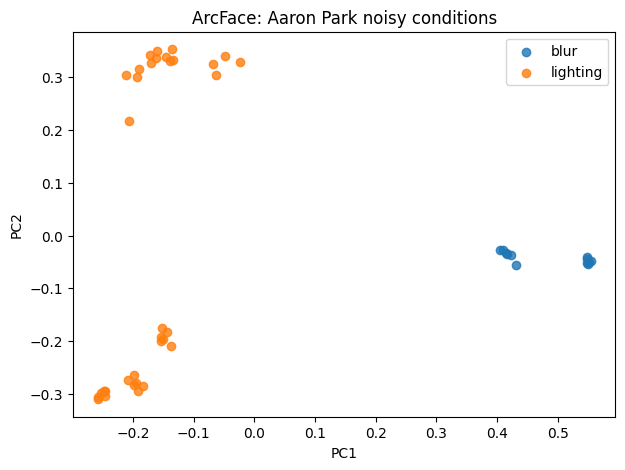

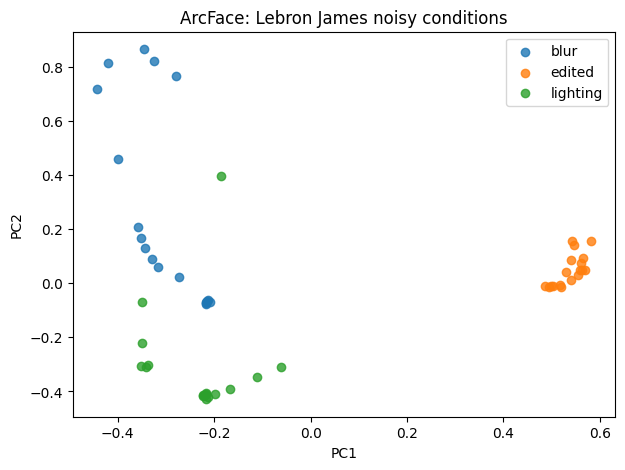

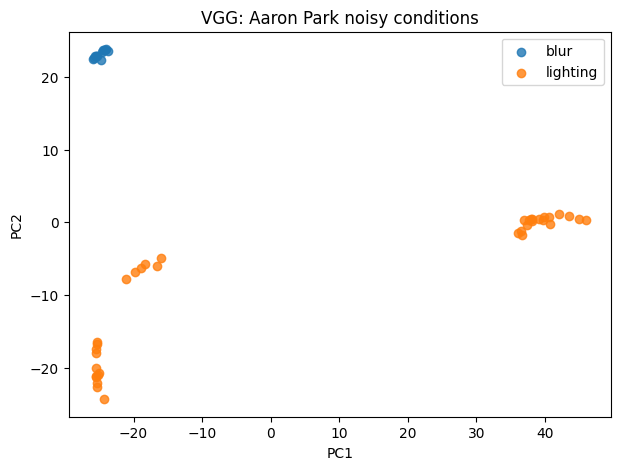

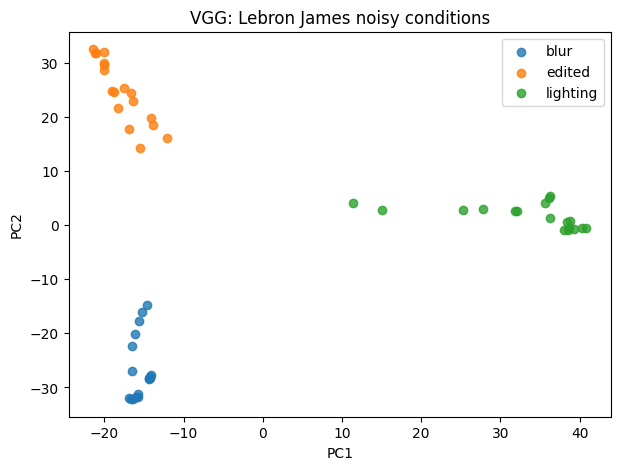

In [45]:
identity_1 = "Aaron Park"
identity_2 = "Lebron James"

plot_identity_conditions(
    arc_probe_features[arc_noisy_mask],
    arc_probe_labels[arc_noisy_mask],
    arc_probe_conditions[arc_noisy_mask],
    identity_1,
    f"ArcFace: {identity_1} noisy conditions"
)

plot_identity_conditions(
    arc_probe_features[arc_noisy_mask],
    arc_probe_labels[arc_noisy_mask],
    arc_probe_conditions[arc_noisy_mask],
    identity_2,
    f"ArcFace: {identity_2} noisy conditions"
)

plot_identity_conditions(
    vgg_probe_features[vgg_noisy_mask],
    vgg_probe_labels[vgg_noisy_mask],
    vgg_probe_conditions[vgg_noisy_mask],
    identity_1,
    f"VGG: {identity_1} noisy conditions"
)

plot_identity_conditions(
    vgg_probe_features[vgg_noisy_mask],
    vgg_probe_labels[vgg_noisy_mask],
    vgg_probe_conditions[vgg_noisy_mask],
    identity_2,
    f"VGG: {identity_2} noisy conditions"
)

In [46]:
def plot_gallery_vs_noisy(gallery_features, gallery_labels, probe_features, probe_labels, probe_conditions, identity_name, title):
    gallery_mask = gallery_labels == identity_name
    probe_mask = probe_labels == identity_name

    X_gallery = gallery_features[gallery_mask]
    X_probe = probe_features[probe_mask]
    c_probe = probe_conditions[probe_mask]

    if len(X_gallery) == 0 or len(X_probe) == 0:
        print(f"Not enough data for {identity_name}")
        return

    X_all = np.vstack([X_gallery, X_probe])
    labels_all = np.array(["gallery_clean"] * len(X_gallery) + list(c_probe))

    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X_all)

    plt.figure(figsize=(7,5))
    for cond in np.unique(labels_all):
        mask = labels_all == cond
        plt.scatter(X2[mask, 0], X2[mask, 1], label=cond, alpha=0.8)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

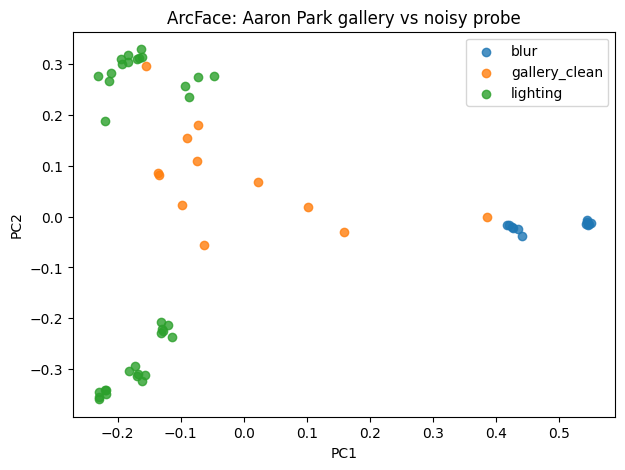

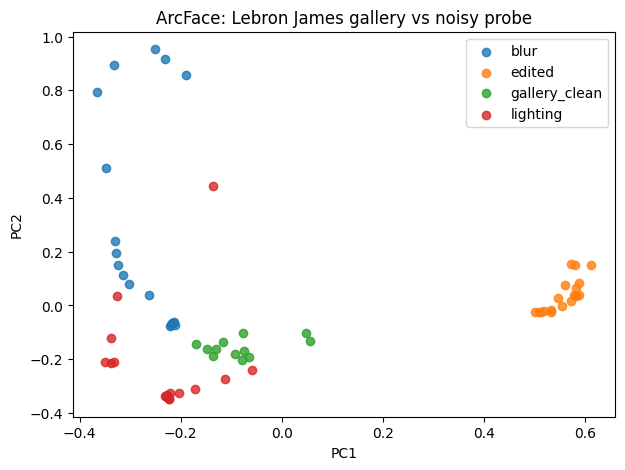

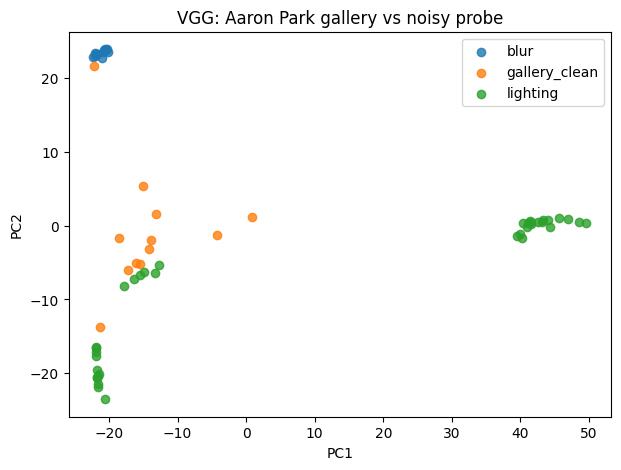

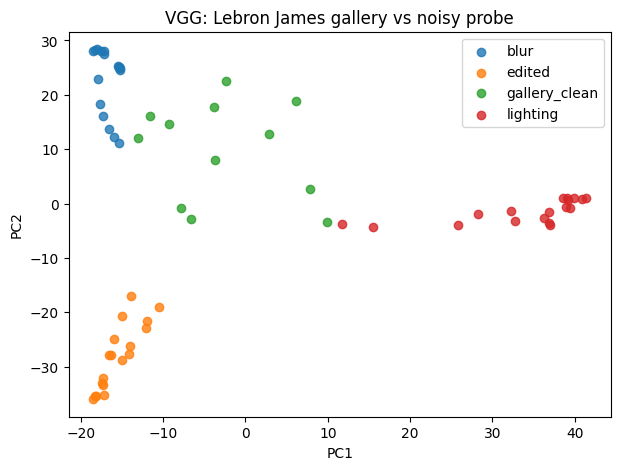

In [48]:
plot_gallery_vs_noisy(
    arc_gallery_features, arc_gallery_labels,
    arc_probe_features[arc_noisy_mask], arc_probe_labels[arc_noisy_mask], arc_probe_conditions[arc_noisy_mask],
    "Aaron Park",
    "ArcFace: Aaron Park gallery vs noisy probe"
)

plot_gallery_vs_noisy(
    arc_gallery_features, arc_gallery_labels,
    arc_probe_features[arc_noisy_mask], arc_probe_labels[arc_noisy_mask], arc_probe_conditions[arc_noisy_mask],
    "Lebron James",
    "ArcFace: Lebron James gallery vs noisy probe"
)

plot_gallery_vs_noisy(
    vgg_gallery_features, vgg_gallery_labels,
    vgg_probe_features[vgg_noisy_mask], vgg_probe_labels[vgg_noisy_mask], vgg_probe_conditions[vgg_noisy_mask],
    "Aaron Park",
    "VGG: Aaron Park gallery vs noisy probe"
)

plot_gallery_vs_noisy(
    vgg_gallery_features, vgg_gallery_labels,
    vgg_probe_features[vgg_noisy_mask], vgg_probe_labels[vgg_noisy_mask], vgg_probe_conditions[vgg_noisy_mask],
    "Lebron James",
    "VGG: Lebron James gallery vs noisy probe"
)